# Dimensionality reduction and data visualization


the idea is simple:
* map each high-dimensional vector to a single vector in a low-dimensional space

### Goals for today:
* get familiar with the concepts of dimensionality reduction and data visualiation
* see how tSNE works on simple data (3D->2D)
* see how it works on our mnist dataset (optionally fashion mnist)

tSNE (t-distributed stochastic neighbourhood embedding) to understand the the structure of the mnist (digits) dataset some more.
unsupervised learning method wihch will allow us to visualize the high-dimensional data in 2D (or 3D if we want)

### Technicalities

we use sklearn implementation of tSNE -- usage is very similar to k-means

today we will use:
* initialize model (setting some parameters)
* .fit function
* .embeddings_ (the result)
* we will normally use.fit_transorm function instead of the two steps above. it fits and returns the embedding in one go.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist, fashion_mnist
from sklearn.manifold import TSNE

# technicalities below
plt.rcParams["figure.figsize"] = (15,15) # larger default figures!

### 3D -> 2D intuition and technicalities
we'll generate some silly 3D data and then see how visualizing it in 2D works

##### dataset representation
dataet = matrix(N,D) 
- N = number of samples
- D = features

for example, 60_000 images, 784 pixels each

matrix -> X.shape = (60_000, 784)

we compute:

Y = f(X), where Y.shape (60_000, 2).

so every image becomes a 2D point

##### visualizing clusters
now you can plot:

plt.scatter(Y[:,0], Y[:,1])

if t-SNE works well:

you can see clusters:
cluster of 0s
cluster of 1s
cluster of 2s ...

Even though the algorithm never sal labels. 

**this is the unsupervised learning**

#### The ML Pipeline (conceptually)
1. load data set
2. flatten images
3. run t-sne
4. plot

**in other words,**

1. high dimensional dataset
2. computer pairwise similarity
3. optimize 2D coordinates
4. visualize clusters


### Data generation 

In [10]:
def generate_3d_blob(n, thinness=5):
    '''No need to read the implementations!'''
    X3 = np.random.randn(n, 3)
    ns = np.linalg.norm(X3, axis=1, keepdims=True)
    X3 /= ns
    X3 *= (1 + np.random.randn(n, 1)/thinness)
    return X3


def generate_vaguely_interesting_3D_data(n):
    '''
    Returns roughly n points in 3D in a vaguely interesting configuration.

    No need to read the implementation!
    '''
    num_extra = int(np.sqrt(n))
    blobs = [generate_3d_blob(n//3) + np.random.randn(3)*5 for _ in range(3)]
    extra = []
    for b1 in blobs:
        for b2 in blobs:
            c1 = np.mean(b1, axis=0)
            c2 = np.mean(b2, axis=0)
            extra.append(np.linspace(c1, c2, num_extra)
                         + np.random.randn(num_extra, 3)/3)

    return np.concatenate(blobs + extra)

### tSNE on synthetic 3D data

(np.float64(-10.855865574167048),
 np.float64(7.166517119508356),
 np.float64(-12.039071671823699),
 np.float64(5.983311021851705),
 np.float64(-4.980005914420778),
 np.float64(8.536781105835777))

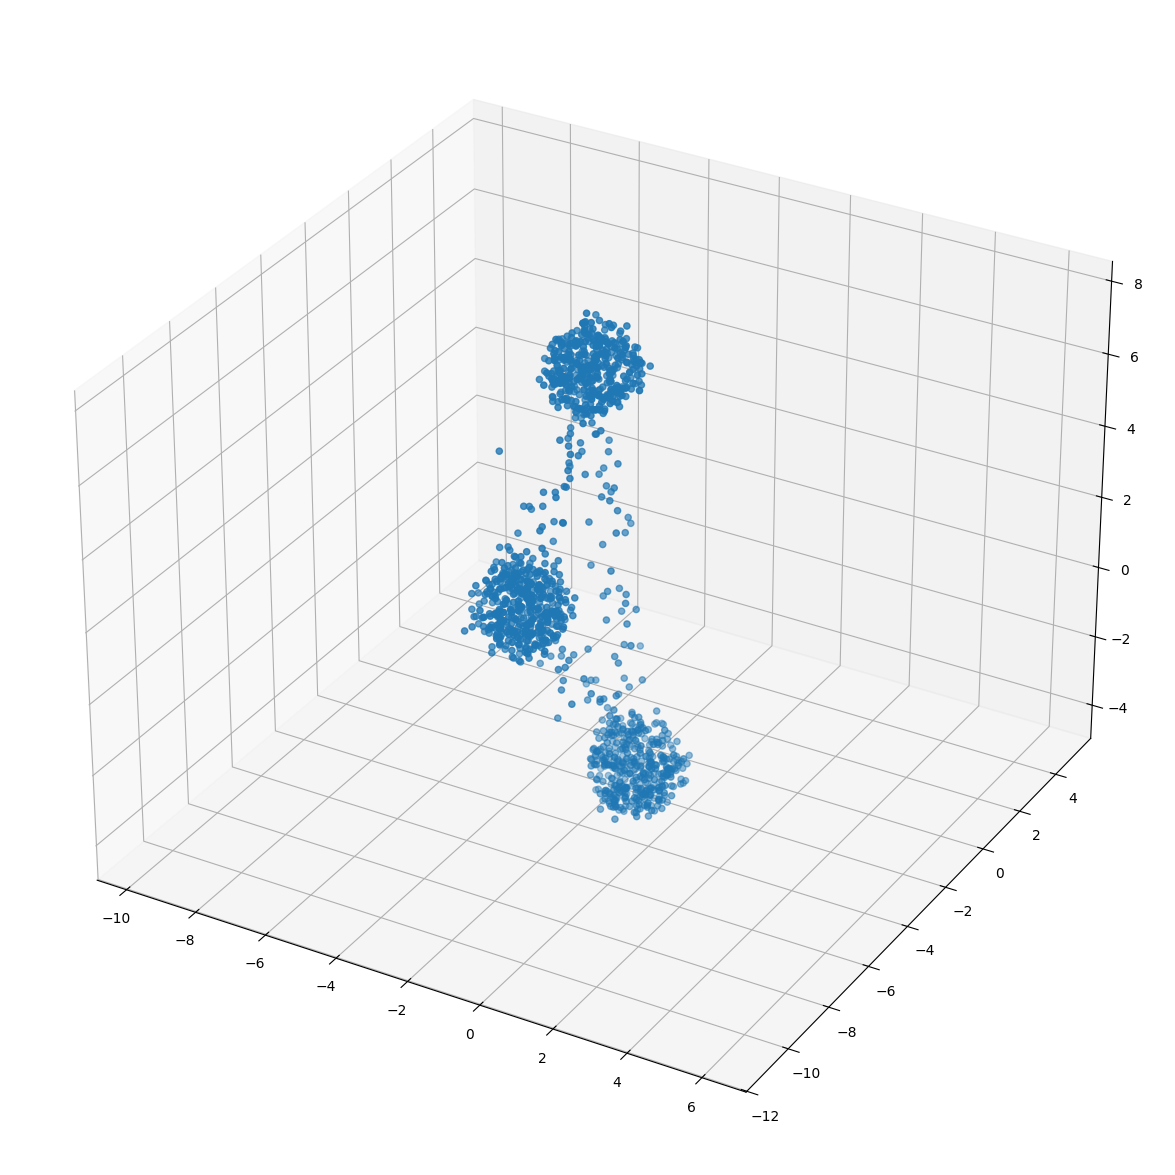

In [11]:
np.random.seed(5+1)
X3 = generate_vaguely_interesting_3D_data(1000)
ax = plt.axes(projection='3d')
ax.scatter3D(X3.T[0], X3.T[1], X3.T[2]) # we pass x, y, z now!
ax.axis('equal')

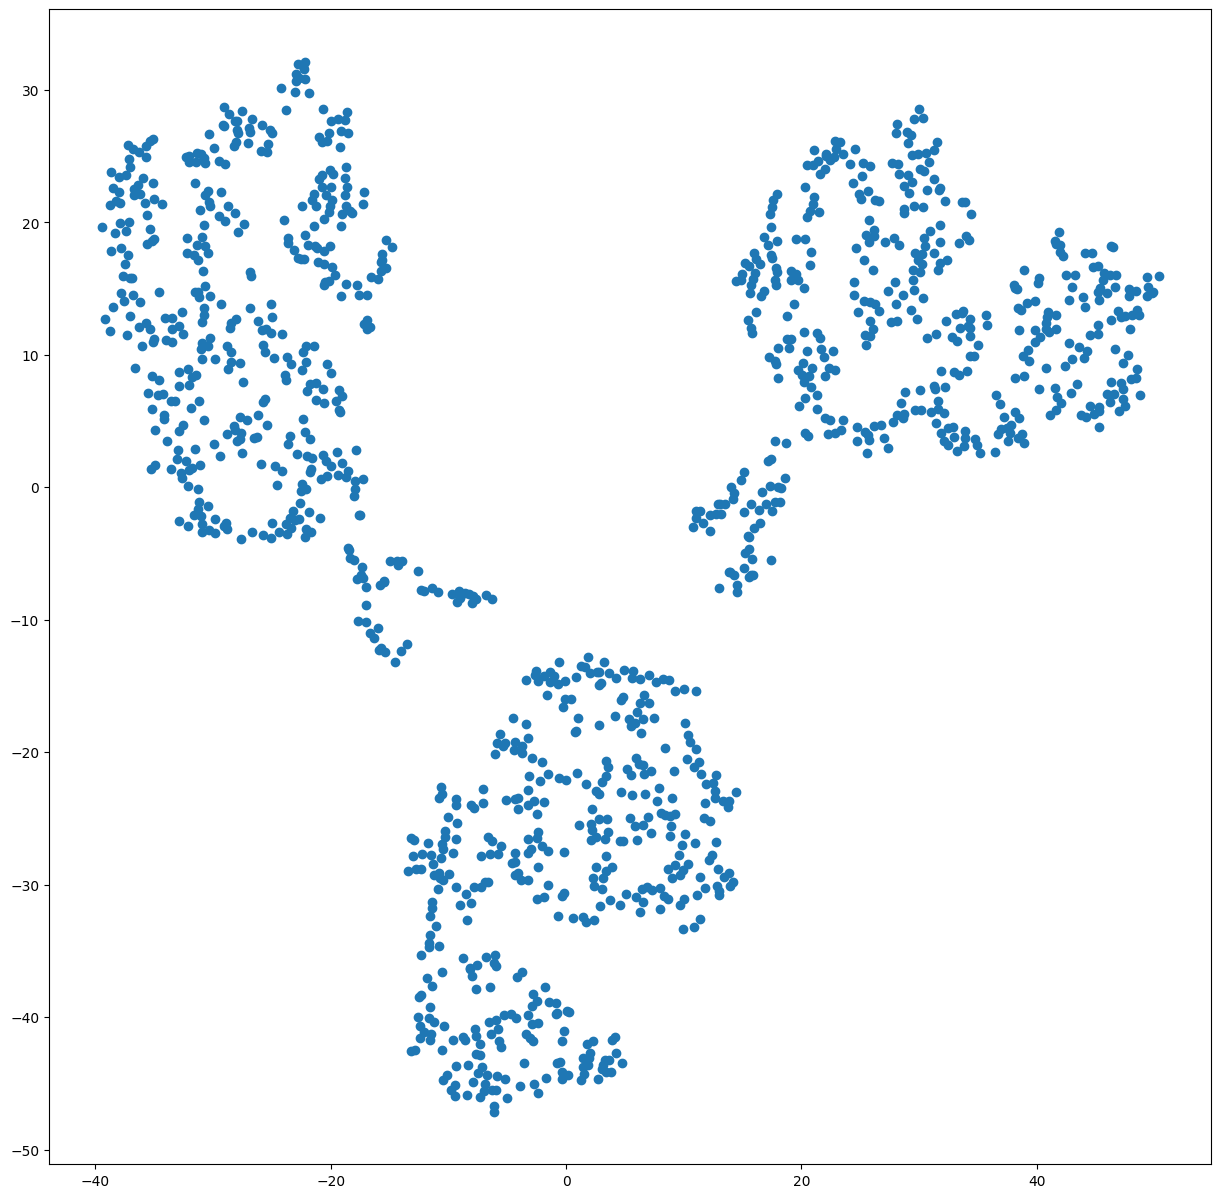

In [12]:
tsne = TSNE(n_components=2)  # the 2 means we want to reduce the dimension to 2

X2 = tsne.fit_transform(X3)

# alternative, similar to how we used kMeans:
# tsne.fit(X3)
# X2 = tsne.embedding_

# now the i-th point of X2 is a 2d-vector representing the i-th vector in X3!
# so we can plot a 2d representation of our data
plt.scatter(X2.T[0], X2.T[1])